LEARNING CURVES

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


Carico il dataset

In [32]:
data=load_breast_cancer()
X=data.data
y=data.target

Controllo distribuzine dei dati

In [33]:
X=pd.DataFrame(data.data, columns=data.feature_names)
y=pd.Series(data.target,name="target")

df=X.copy()
df["target"]=y
display(df)
print (df.groupby("target").mean())
print (df.groupby("target").mean())
df["target"].value_counts()  #ho anche valori nulli
df.groupby("target").count()  #conta i valori non nulli per colonna

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


        mean radius  mean texture  mean perimeter   mean area  \
target                                                          
0         17.462830     21.604906      115.365377  978.376415   
1         12.146524     17.914762       78.075406  462.790196   

        mean smoothness  mean compactness  mean concavity  \
target                                                      
0              0.102898          0.145188        0.160775   
1              0.092478          0.080085        0.046058   

        mean concave points  mean symmetry  mean fractal dimension  ...  \
target                                                              ...   
0                  0.087990       0.192909                0.062680  ...   
1                  0.025717       0.174186                0.062867  ...   

        worst radius  worst texture  worst perimeter   worst area  \
target                                                              
0          21.134811      29.318208       141.370330  1

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,212
1,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,357


In [35]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
# 4. Dimensioni progressive del training set
train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

In [37]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print("Train sizes:", train_sizes)
print("Train mean:", np.round(train_mean, 4))
print("Validation mean:", np.round(val_mean, 4))

Train sizes: [ 45 147 250 352 455]
Train mean: [0.9867 0.9864 0.9824 0.9835 0.9881]
Validation mean: [0.8594 0.9543 0.9631 0.9701 0.9737]


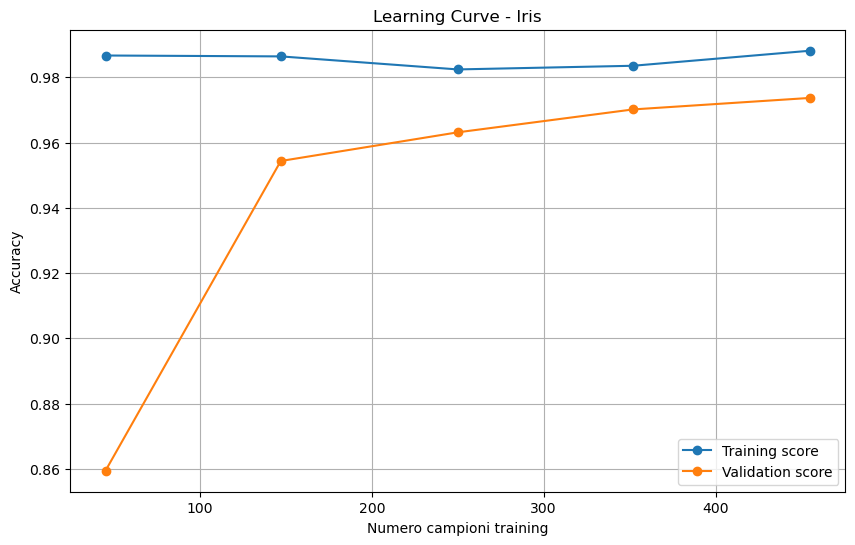

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
plt.xlabel("Numero campioni training")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Iris")
plt.grid(True)
plt.legend()
plt.show()

il modello beneficia chiaramente dall'aumento dei dati e migliora progressivamente la capacità di generalizzazione.
Validation è costante in crescita, quidni stampa imparando bene e meglio
La fase iniziale è di forte crescita per poi convergere verso la fine del trainig. Quando la curva si appiattisce vuol dire che sta arrivando al limite del problema, ha già imparato tutto, ulteriori dati migliorano poco il modello, comportamento corretto